In [1]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()

In [2]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return O, operator_list

def commute(A,B):
    return A@B-B@A
def diagonalize(op,basis):
    return basis.T@op@basis

In [3]:
###### Model parameters
#Length of chain
L = 12
#X field
J1 = 1 #NN term 
J2 = 0
h0 = 1
###Using Quantum_Operator to build hamitlonian 
basis = spin_basis_1d(L, pauli = -1,pblock=1,kblock=0)
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+1)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H.todense())
#Convert matrix to array
V = np.array(V)
H = array(H.todense())
##################


In [4]:
ns = np.arange(1,8+1)
Pn = [array(fin_string(n,"x")[0].todense()) for n in ns]
#Compute partialH: 

single_site = [ [1, i] for i in range(L)]
z_single_site = [["z", single_site]]
operator_dict=dict(S=z_single_site)
partialH= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
partialH = array(partialH.todense())

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:27: RuntimeWarning: divide by zero encountered in matmul
  imshow(np.abs(V.T@xlongy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:27: RuntimeWarning: overflow encountered in matmul
  imshow(np.abs(V.T@xlongy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:27: RuntimeWarning: invalid value encountered in matmul
  imshow(np.abs(V.T@xlongy@V))


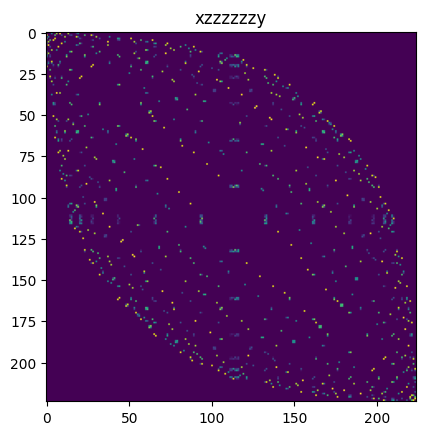

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:31: RuntimeWarning: divide by zero encountered in matmul
  imshow(np.abs(V.T@xzzy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:31: RuntimeWarning: overflow encountered in matmul
  imshow(np.abs(V.T@xzzy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:31: RuntimeWarning: invalid value encountered in matmul
  imshow(np.abs(V.T@xzzy@V))


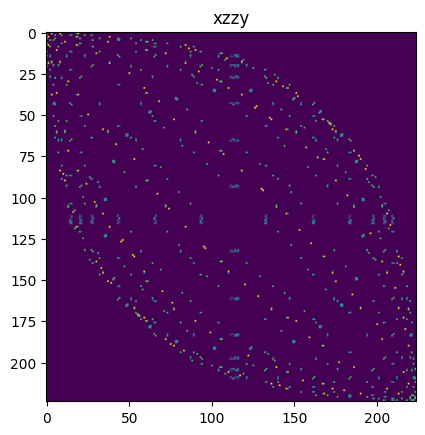

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:34: RuntimeWarning: divide by zero encountered in matmul
  imshow(np.abs(V.T@xzy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:34: RuntimeWarning: overflow encountered in matmul
  imshow(np.abs(V.T@xzy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:34: RuntimeWarning: invalid value encountered in matmul
  imshow(np.abs(V.T@xzy@V))


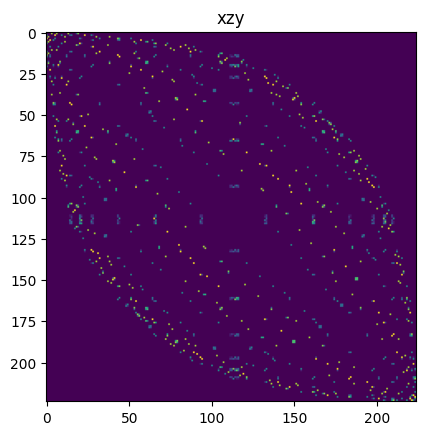

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:37: RuntimeWarning: divide by zero encountered in matmul
  imshow(np.abs(V.T@xy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:37: RuntimeWarning: overflow encountered in matmul
  imshow(np.abs(V.T@xy@V))
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/909441646.py:37: RuntimeWarning: invalid value encountered in matmul
  imshow(np.abs(V.T@xy@V))


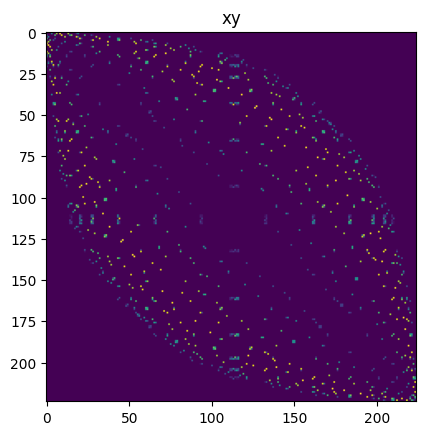

In [5]:
#Compute xy: 
sites = [ [1,i,(i+1)%L] for i in range(L)]
terms = [["xy",sites],["yx",sites]]
operator_dict = dict(S=terms)
xy = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
xy= array(xy.todense())
#Compute xzy:
sites = [ [1,i,(i+1)%L,(i+2)%L] for i in range(L)]
terms = [ ["xzy",sites], ["yzx",sites]]
operator_dict = dict(S=terms)
xzy = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
xzy= array(xzy.todense())
#Compute xzzy:
sites = [ [1,i,(i+1)%L,(i+2)%L,(i+3)%L] for i in range(L)]
terms = [ ["xzzy",sites], ["yzzx",sites]]
operator_dict = dict(S=terms)
xzzy = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
xzzy= array(xzzy.todense())

#Compute xzzzzzy:
sites = [ [1,i,(i+1)%L,(i+2)%L,(i+3)%L,(i+4)%L,(i+5)%L,(i+6)%L,(i+7)%L] for i in range(L)]
terms = [ ["xzzzzzzy",sites], ["yzzzzzzx",sites]]
operator_dict = dict(S=terms)
xlongy = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
xlongy= array(xlongy.todense())
title("xzzzzzzy")
imshow(np.abs(V.T@xlongy@V))
show()

title("xzzy")
imshow(np.abs(V.T@xzzy@V))
show()
title("xzy")
imshow(np.abs(V.T@xzy@V))
show()
title("xy")
imshow(np.abs(V.T@xy@V))
show()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


(0.0, 15.0)

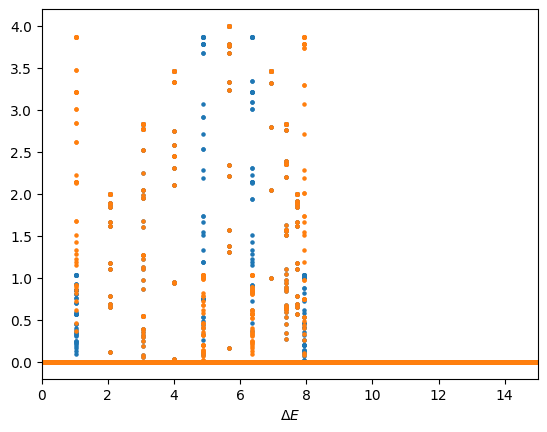

In [6]:
dE=E[:,None]-E[None,:]
dE= dE.ravel()

scatter(dE,np.abs(diagonalize(xy,V)).ravel(),s=5)
#scatter(dE,np.abs(diagonalize(xzy,V)).ravel(),s=5)
#scatter(dE,np.abs(diagonalize(xzzy,V)).ravel(),s=5)
scatter(dE,np.abs(diagonalize(xlongy,V)).ravel(),s=5)
xlabel(r"$\Delta E$")
plt.xlim(0,15)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


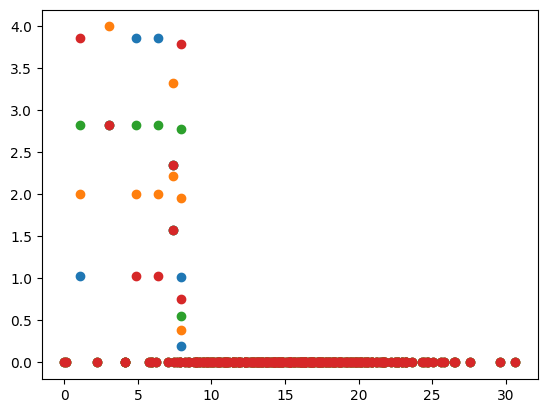

In [7]:
dE = E[:,None]-E[None,:]
scatter(dE[:,0],np.abs(diagonalize(xy,V)[:,0]))
scatter(dE[:,0],np.abs(diagonalize(xzy,V)[:,0]))
scatter(dE[:,0],np.abs(diagonalize(xzzy,V)[:,0]))
scatter(dE[:,0],np.abs(diagonalize(xlongy,V)[:,0]))

In [8]:
A1 = commute(H,partialH)
def next(A,H):
    return commute(H,commute(H,A))
A2 = next(A1,H)
A3 = next(A2,H)
A4 = next(A3,H)
A5 = next(A4,H)
As = [A1,A2,A3,A4,A5]
Ad = [diagonalize(A,V) for A in As]

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


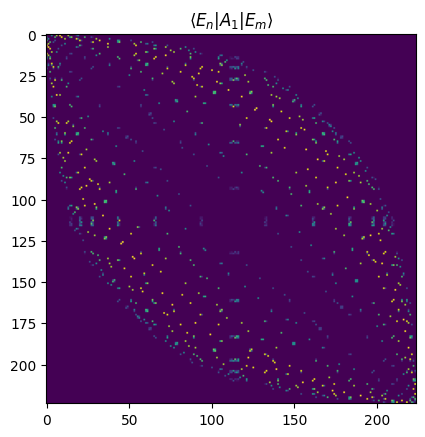

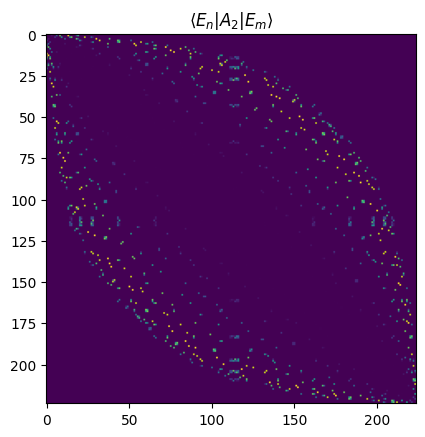

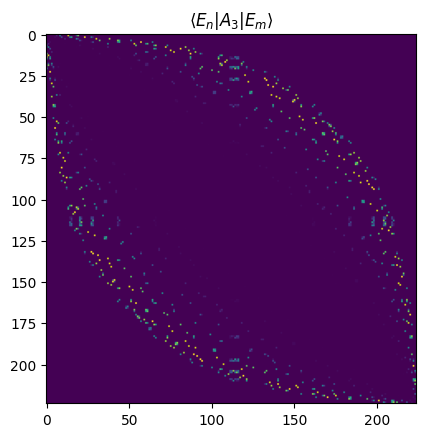

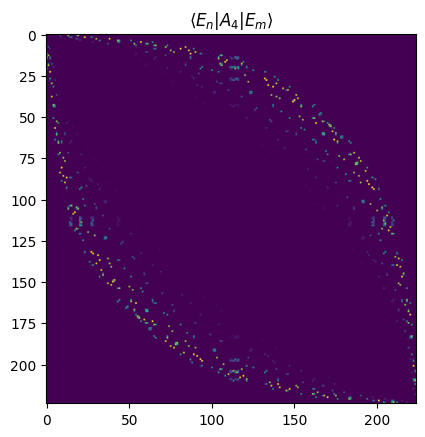

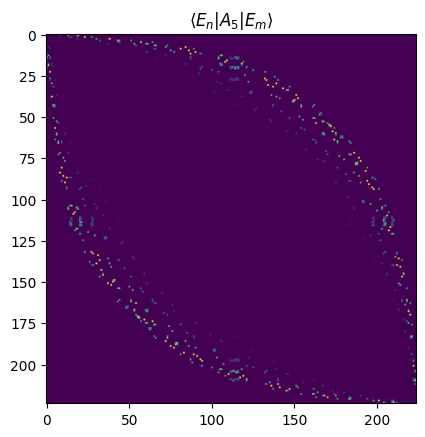

In [9]:
for i,A in enumerate(Ad):
    imshow(np.abs(A))
    title(rf"$\langle E_n | A_{i+1} |E_m \rangle$")
    show()

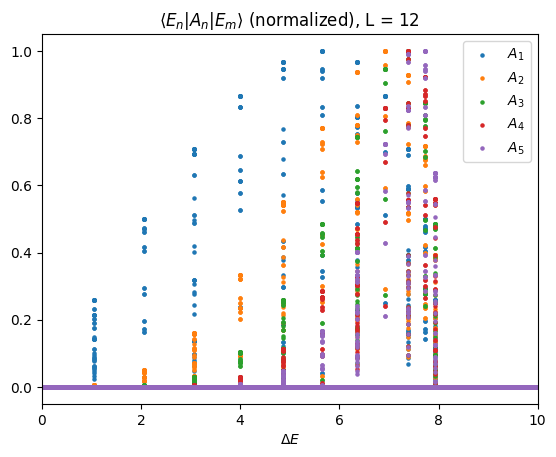

In [10]:
for i,A in enumerate(Ad):
    scatter(dE,np.abs(A).ravel()/np.max(np.abs(A)),s=5,label=rf"$A_{i+1}$")
    title(rf"$\langle E_n | A_n |E_m \rangle$ (normalized), L = {L}")
    xlabel(r"$\Delta E$")
    plt.xlim(0,10)
    #show()
legend()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


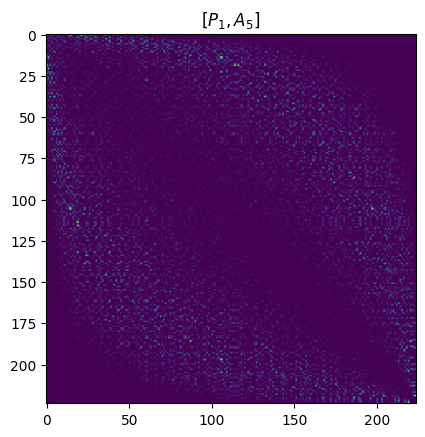

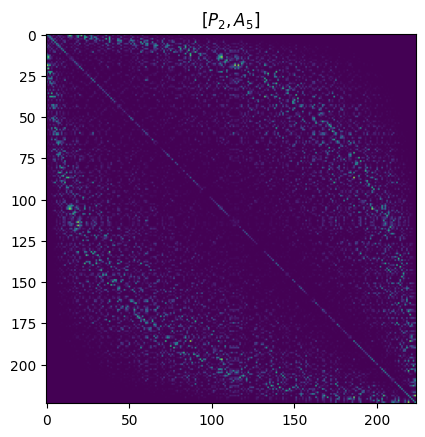

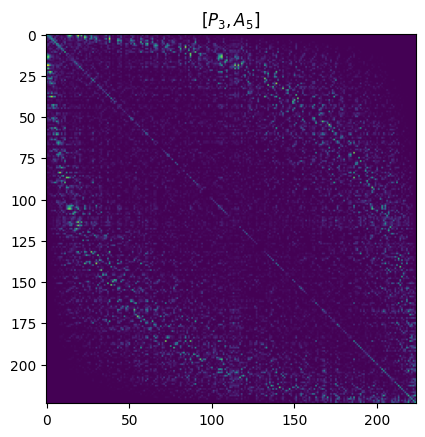

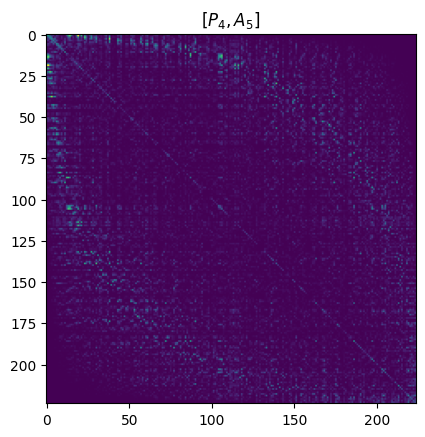

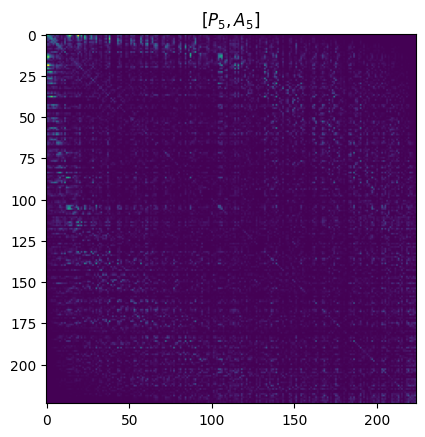

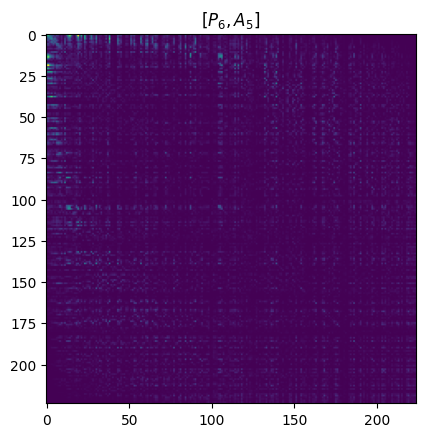

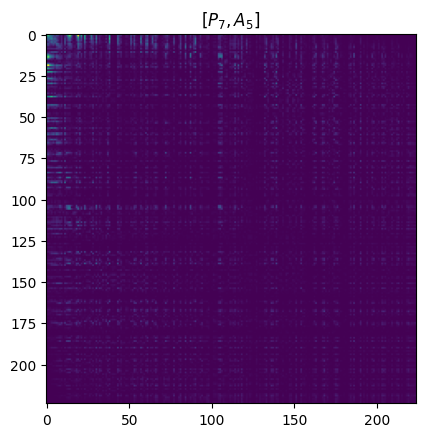

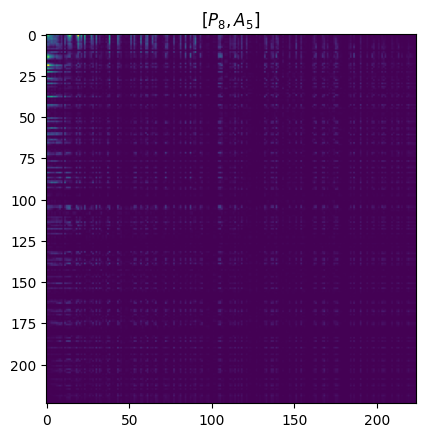

In [16]:
j=4
for n,P in zip(ns,Pn):
    Op = commute(P,As[j])
    Op = diagonalize(Op,V)
    imshow(np.abs(Op)/np.max(np.abs(Op)))
    title(rf"$[P_{n},A_{j+1}]$")
    show()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:57: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:57: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:57: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_44183/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


(0.0, 30.0)

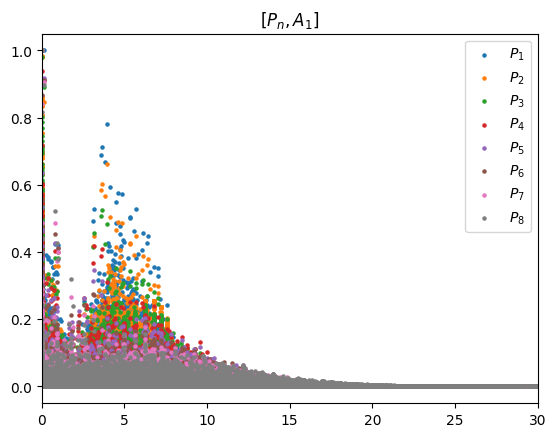

In [134]:
j=0
for n,P in zip(ns,Pn):
    Op = commute(P,As[j])
    Op = diagonalize(Op,V)
    Op = np.abs(Op)/np.max(np.abs(Op))
    x = dE.ravel()
    x = x[x>=0]
    Op_plot = Op.ravel()
    Op_plot = Op_plot[dE.ravel()>0]
    scatter(dE.ravel(),Op.ravel(),s=5,label=rf"$P_{n}$")
title(rf"$[P_n,A_{j+1}]$")
legend()
plt.xlim(0,30)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: divide by zero encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: overflow encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:57: RuntimeWarning: invalid value encountered in matmul
  return A@B-B@A
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: divide by zero encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: overflow encountered in matmul
  return basis.T@op@basis
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_45440/891760244.py:59: RuntimeWarning: invalid value encountered in matmul
  return basis.T@op@basis


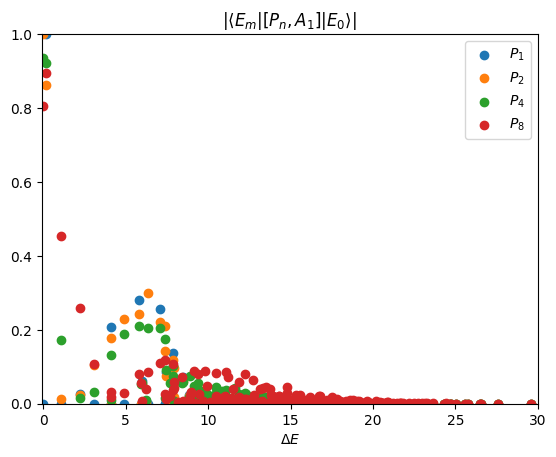

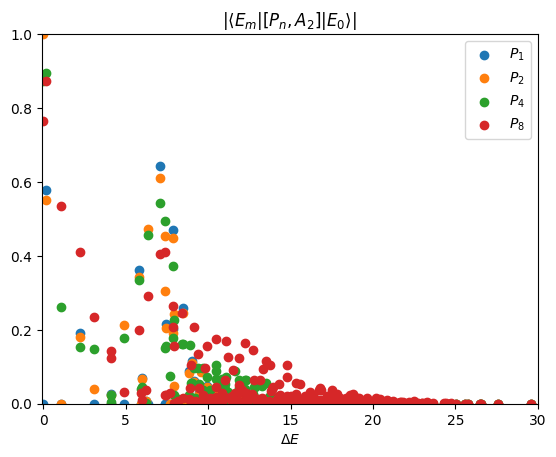

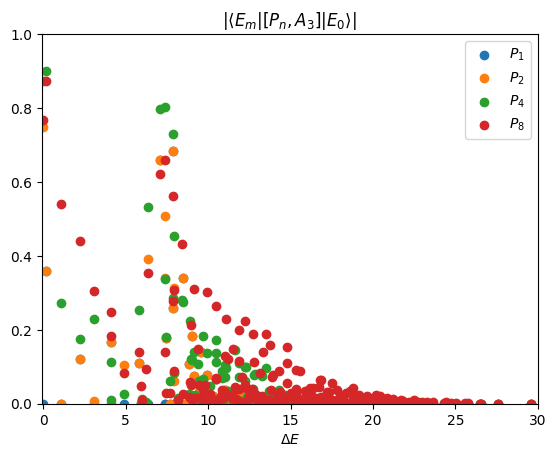

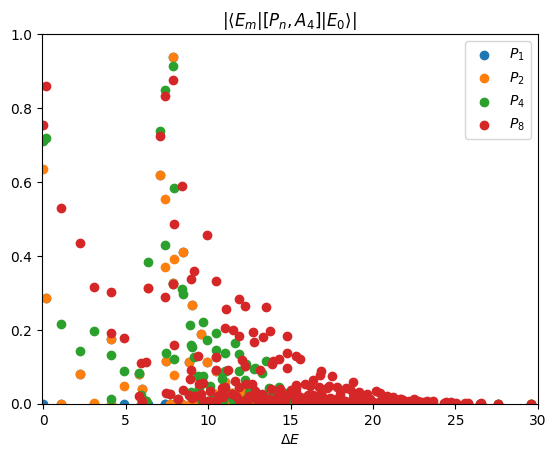

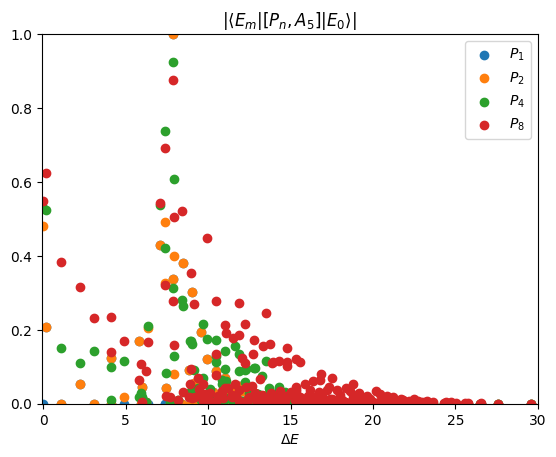

In [19]:
for j in range(len(As)):
    for n,P in zip(ns,Pn):
        if n==1 or n == 2  or n==4 or n ==8:
            Op = commute(P,As[j])
            Op = diagonalize(Op,V)
            Op = np.abs(Op)/np.max(np.abs(Op))
            x = dE[:,0]
           # x = x[x>=0]
            Op_plot = Op[:,0]
            #Op_plot = Op_plot[dE.ravel()>0]
            scatter(x,Op_plot,label=rf"$P_{n}$")
    title(rf"$|\langle E_m| [P_n,A_{j+1}]|E_0 \rangle |$")
    xlabel(rf"$\Delta E$")
    legend()
    plt.xlim(-.1,30)
    plt.ylim(0,1)
    show()